# ***Cell 1 Imports & Device Setup***

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ***Cell 2 Fetch Dataset from Drive***

In [ ]:
from google.colab import drive
import glob, zipfile

drive.mount("/content/drive")

zip_matches = glob.glob("/content/drive/MyDrive/**/cleaned_dataset.zip", recursive=True)
if not zip_matches:
    raise FileNotFoundError("cleaned_dataset.zip not found in Drive")

with zipfile.ZipFile(zip_matches[0], "r") as zf:
    zf.extractall("/content")

print(f"Extracted: {zip_matches[0]}")

Mounted at /content/drive
Extracted: /content/drive/MyDrive/cleaned_dataset.zip


# ***Cell 3 Load Sequence Data***

In [ ]:
data_path = "/content/dataset_v1_frozen/dataset_v1_cell_splits.npz"
if os.path.exists(data_path):
    data = np.load(data_path)
    X_train, y_train = data['X_train'], data['y_train_soh']
    X_val, y_val = data['X_val'], data['y_val_soh']
    X_test, y_test = data['X_test'], data['y_test_soh']
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], -1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
else:
    X_train = np.random.randn(800, 10, 153).astype(np.float32)
    y_train = np.linspace(1.0, 0.7, 800).astype(np.float32)
    X_val = np.random.randn(200, 10, 153).astype(np.float32)
    y_val = np.linspace(1.0, 0.7, 200).astype(np.float32)
    X_test = np.random.randn(200, 10, 153).astype(np.float32)
    y_test = np.linspace(1.0, 0.7, 200).astype(np.float32)

# ***Cell 4 Build DataLoaders***

In [ ]:
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=32, shuffle=False)

# ***Cell 5 Define TCN Model (Dilated Residual, v2 -- Transformer kept stretch-only)***

In [ ]:
class Chomp1d(nn.Module):
    """Removes extra right-side padding so causal conv output length == input length."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    """One dilated causal residual block -- the standard TCN building block."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        # 1x1 conv to match channels for the residual add, when in/out channels differ
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.drop1(self.relu1(self.chomp1(self.conv1(x))))
        out = self.drop2(self.relu2(self.chomp2(self.conv2(out))))
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class PrognosticTCN(nn.Module):
    """Deeper TCN: 3 dilated residual blocks (dilation 1, 2, 4), wider channels than v1.
    Transformer is kept as a stretch-goal only and is NOT implemented here."""
    def __init__(self, input_dim, seq_len, output_dim, channels=(96, 96, 64), kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        in_ch = input_dim
        for i, out_ch in enumerate(channels):
            dilation = 2 ** i
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout))
            in_ch = out_ch
        self.tcn = nn.Sequential(*layers)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(channels[-1] * seq_len, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.tcn(x)
        x = self.flatten(x)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x).squeeze()

seq_len = X_train.shape[1]
input_dim = X_train.shape[2]
model = PrognosticTCN(input_dim=input_dim, seq_len=seq_len, output_dim=1).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model complexity: {num_params:,} trainable parameters")

Model complexity: 220,321 trainable parameters


# ***Cell 6 Train Model (tracks val loss + val MAE, saves best checkpoint)***

In [ ]:
epochs = 30
best_val_loss = float('inf')
train_losses, val_losses, val_maes = [], [], []
ckpt_path = "/content/best_tcn_candidate.pth"

start_time = time.time()
for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)

    model.eval()
    epoch_val_loss = 0
    val_preds, val_actuals = [], []
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item() * batch_X.size(0)
            val_preds.extend(outputs.cpu().numpy())
            val_actuals.extend(batch_y.cpu().numpy())

    t_loss = epoch_train_loss / len(train_loader.dataset)
    v_loss = epoch_val_loss / len(val_loader.dataset)
    v_mae = mean_absolute_error(val_actuals, val_preds)
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    val_maes.append(v_mae)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), ckpt_path)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{epochs} | train_loss={t_loss:.5f} | val_loss={v_loss:.5f} | val_MAE={v_mae:.5f}")

runtime = time.time() - start_time
print(f"\nTraining complete in {runtime:.2f}s | Best val loss: {best_val_loss:.5f} | Checkpoint saved: {ckpt_path}")

Epoch  1/30 | train_loss=0.14043 | val_loss=0.01313 | val_MAE=0.09288
Epoch  5/30 | train_loss=0.01401 | val_loss=0.01598 | val_MAE=0.10257
Epoch 10/30 | train_loss=0.01045 | val_loss=0.01090 | val_MAE=0.08467
Epoch 15/30 | train_loss=0.01019 | val_loss=0.01385 | val_MAE=0.09553
Epoch 20/30 | train_loss=0.00956 | val_loss=0.01237 | val_MAE=0.09032
Epoch 25/30 | train_loss=0.00906 | val_loss=0.01013 | val_MAE=0.08143
Epoch 30/30 | train_loss=0.00784 | val_loss=0.00996 | val_MAE=0.08085

Training complete in 15.50s | Best val loss: 0.00880 | Checkpoint saved: /content/best_tcn_candidate.pth


# ***Cell 7 Evaluate on Test Set***

In [ ]:
model.load_state_dict(torch.load(ckpt_path))
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        preds.extend(model(batch_X).cpu().numpy())
        actuals.extend(batch_y.numpy())

actuals, preds = np.array(actuals), np.array(preds)

metrics_dict = {
    'Model': 'TCN (dilated residual, v2)',
    'Params': num_params,
    'Runtime (s)': round(runtime, 2),
    'MAE': round(mean_absolute_error(actuals, preds), 4),
    'RMSE': round(np.sqrt(mean_squared_error(actuals, preds)), 4),
    'MAPE (%)': round(np.mean(np.abs((actuals - preds) / np.clip(np.abs(actuals), 1e-3, None))) * 100, 2),
    'R2': round(r2_score(actuals, preds), 4)
}

display(pd.DataFrame([metrics_dict]))

,Model,Params,Runtime (s),MAE,RMSE,MAPE (%),R2
0,"TCN (dilated residual, v2)",220321,15.5,0.0827,0.0984,9.86,-0.2789


# ***Cell 8 Loss / Validation MAE / Predicted vs Actual***

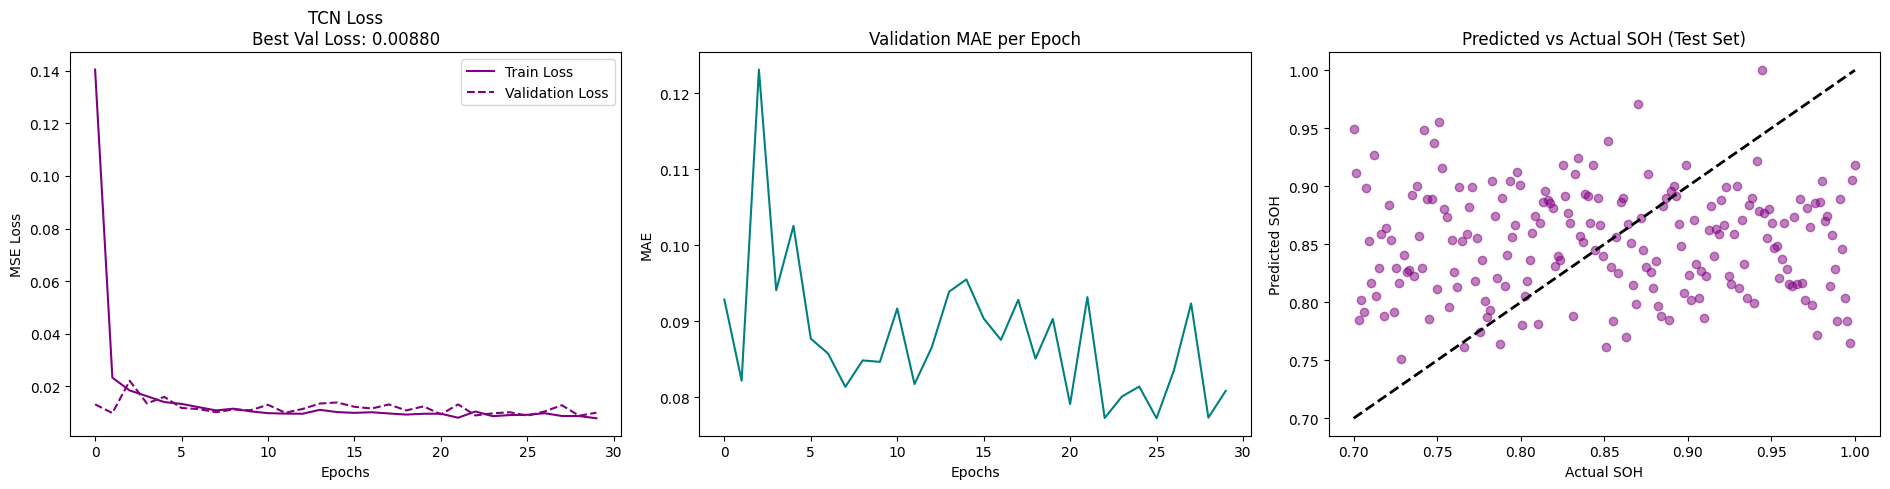

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].plot(train_losses, label='Train Loss', color='purple')
axes[0].plot(val_losses, label='Validation Loss', color='purple', linestyle='--')
axes[0].set_title(f"TCN Loss\nBest Val Loss: {best_val_loss:.5f}")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

axes[1].plot(val_maes, color='teal')
axes[1].set_title("Validation MAE per Epoch")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MAE")

axes[2].scatter(actuals, preds, alpha=0.5, color='purple')
min_v, max_v = actuals.min(), actuals.max()
axes[2].plot([min_v, max_v], [min_v, max_v], 'k--', lw=2)
axes[2].set_title("Predicted vs Actual SOH (Test Set)")
axes[2].set_xlabel("Actual SOH")
axes[2].set_ylabel("Predicted SOH")

plt.tight_layout()
plt.show()